# Likelihood Ratio Attack
This notebook is an implementation of the Likelihood Ratio Attack with phi scores using scaled logits and other variations

# Sampling the public data

In [ ]:
import torch
import pandas as pd
from torch.utils.data import Dataset
from torchvision.models import resnet18
import torchvision.transforms as transforms
from pathlib import Path
import numpy as np
from torch.utils.data import Subset
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
#Config
PUB_PATH = '/content/pub.pt'
NUM_SHADOWS= 16

In [ ]:
# dataset classes
class TaskDataset(Dataset):
    def __init__(self, transform=None):
        self.ids = []
        self.imgs = []
        self.labels = []
        self.transform = transform

    def __getitem__(self, index):
        id_ = self.ids[index]
        img = self.imgs[index]
        if self.transform is not None:
            img = self.transform(img)
        label = self.labels[index]
        return id_, img, label

    def __len__(self):
        return len(self.ids)


class MembershipDataset(TaskDataset):
    def __init__(self, transform=None):
        super().__init__(transform)
        self.membership = []

    def __getitem__(self, index):
        id_, img, label = super().__getitem__(index)
        return id_, img, label, self.membership[index]

In [ ]:
# load datasets
print("Loading datasets...")
pub_ds = torch.load(PUB_PATH, weights_only=False)
print(f"Public dataset: {len(pub_ds)} samples")

Loading datasets...
Public dataset: 14000 samples


In [ ]:
# normalization (same as training)
MEAN = [0.7406, 0.5331, 0.7059]
STD = [0.1491, 0.1864, 0.1301]

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.Normalize(mean=MEAN, std=STD),
])

pub_ds.transform = transform

# Dataset Sampling for Shadow models

In [ ]:
def sample_shadow_dataset(public_dataset, seed, fraction=0.5):

    np.random.seed(seed)
    n = len(public_dataset)
    indices = np.random.permutation(n)
    train_size = int(fraction * n)
    train_idx = indices[:train_size]
    holdout_idx = indices[train_size:]
    return Subset(public_dataset, train_idx), Subset(public_dataset, holdout_idx), train_idx, holdout_idx

# Shadow Model (ResNet18)

In [ ]:
def build_model():

    model = resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(512, 9)
    return model

In [ ]:
#training loop
# training loop + loss tracking
def train(model, train_loader, device, epochs=20):
    model.to(device)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.01,
        momentum=0.9,
        weight_decay=5e-4,
    )

    criterion = nn.CrossEntropyLoss()

    # store average loss per epoch
    epoch_losses = []

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        total_samples = 0

        for _, x, y, _ in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()

            output = model(x)

            loss = criterion(output, y)

            loss.backward()

            optimizer.step()

            # accumulate weighted by batch size
            batch_size = x.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

        # average epoch loss
        avg_epoch_loss = running_loss / total_samples
        epoch_losses.append(avg_epoch_loss)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_epoch_loss:.4f}")

    return model, epoch_losses

# Compute Scores using Max logits margin

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def compute_phi(model, loader, device):
    """
    Computes LiRA phi scores using max-logit margin:
    phi = true_class_logit - max(other_class_logits)
    """
    scores = {}
    model.eval()

    with torch.no_grad():
        for ids, x, y, _ in loader:
            x, y = x.to(device), y.to(device)

            # Raw logits: shape [batch_size, num_classes]
            logits = model(x)

            # True class logit
            true_logits = logits[torch.arange(len(y), device=device), y]

            # Clone logits so we can mask out the true class
            other_logits = logits.clone()

            # Remove true class from competitor search
            other_logits[torch.arange(len(y), device=device), y] = float("-inf")

            # Maximum competing class logit
            max_other_logits = other_logits.max(dim=1).values

            # Max-logit margin phi
            phi = (true_logits - max_other_logits).cpu().numpy()

            # Store per-sample score
            for i, sample_id in enumerate(ids):
                scores[int(sample_id)] = phi[i]

    return scores


Epoch 1/20 | Loss: 1.2532
Epoch 2/20 | Loss: 0.8578
Epoch 3/20 | Loss: 0.7160
Epoch 4/20 | Loss: 0.5971
Epoch 5/20 | Loss: 0.4853
Epoch 6/20 | Loss: 0.4182
Epoch 7/20 | Loss: 0.3313
Epoch 8/20 | Loss: 0.2466
Epoch 9/20 | Loss: 0.1885
Epoch 10/20 | Loss: 0.1107
Epoch 11/20 | Loss: 0.0738
Epoch 12/20 | Loss: 0.0495
Epoch 13/20 | Loss: 0.0315
Epoch 14/20 | Loss: 0.0349
Epoch 15/20 | Loss: 0.0443
Epoch 16/20 | Loss: 0.0333
Epoch 17/20 | Loss: 0.0191
Epoch 18/20 | Loss: 0.0262
Epoch 19/20 | Loss: 0.0135
Epoch 20/20 | Loss: 0.0143
Shadow model 0 done
Epoch 1/20 | Loss: 1.2706
Epoch 2/20 | Loss: 0.8570
Epoch 3/20 | Loss: 0.6546
Epoch 4/20 | Loss: 0.5284
Epoch 5/20 | Loss: 0.4197
Epoch 6/20 | Loss: 0.3654
Epoch 7/20 | Loss: 0.2990
Epoch 8/20 | Loss: 0.2142
Epoch 9/20 | Loss: 0.1597
Epoch 10/20 | Loss: 0.1293
Epoch 11/20 | Loss: 0.0759
Epoch 12/20 | Loss: 0.0519
Epoch 13/20 | Loss: 0.0328
Epoch 14/20 | Loss: 0.0321
Epoch 15/20 | Loss: 0.0208
Epoch 16/20 | Loss: 0.0155
Epoch 17/20 | Loss: 0.0117

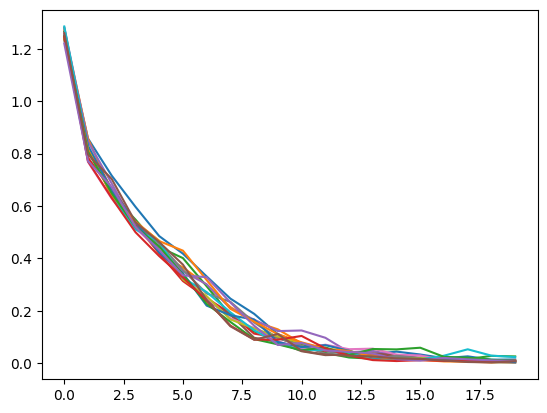

In [ ]:
from torch.utils.data.dataloader import DataLoader
# Compute in and out scores
all_in_scores={}
all_out_scores={}

for shadow_idx in range(NUM_SHADOWS):
  # using different seed value to ensure different random sampling config for each shadow model
  train_ds, holdout_ds, train_idx, holdout_idx= sample_shadow_dataset(pub_ds, seed= 42+ shadow_idx)
  train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
  holdout_loader = DataLoader(holdout_ds, batch_size=128, shuffle=False)

  shadow_model = build_model()
  shadow_model,shadow_loss = train(shadow_model, train_loader, device='cuda')
  plt.plot(shadow_loss, label="train")

  #compute phi scores
  train_scores= compute_phi(shadow_model, train_loader, device='cuda')
  holdout_scores= compute_phi(shadow_model, holdout_loader, device='cuda')
  #save the in and out scores
  for idx, score in train_scores.items():
    all_in_scores.setdefault(idx, []).append(score)
  for idx, score in holdout_scores.items():
    all_out_scores.setdefault(idx, []).append(score)

  print(f'Shadow model {shadow_idx} done')

print(f'in_scores={train_scores}')
print(f'out_scores={holdout_scores}')

# Fit to Gaussian Distribution

mu_in=9.683158874511719, sigma_in=3.372788429260254
mu_out=5.965590476989746, sigma_out=5.831600666046143


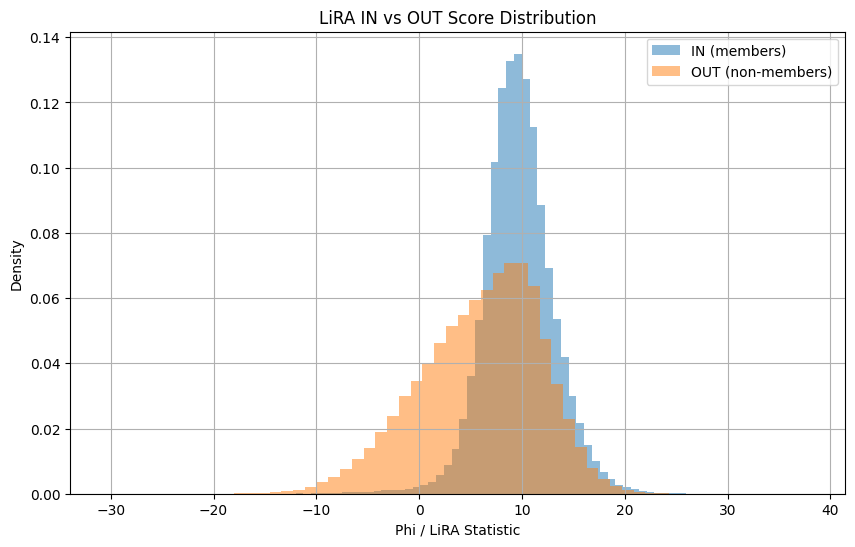

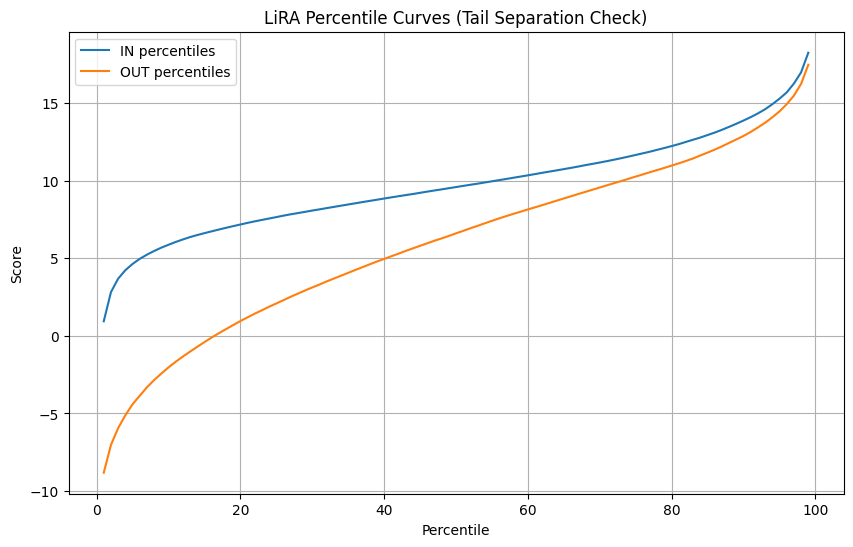

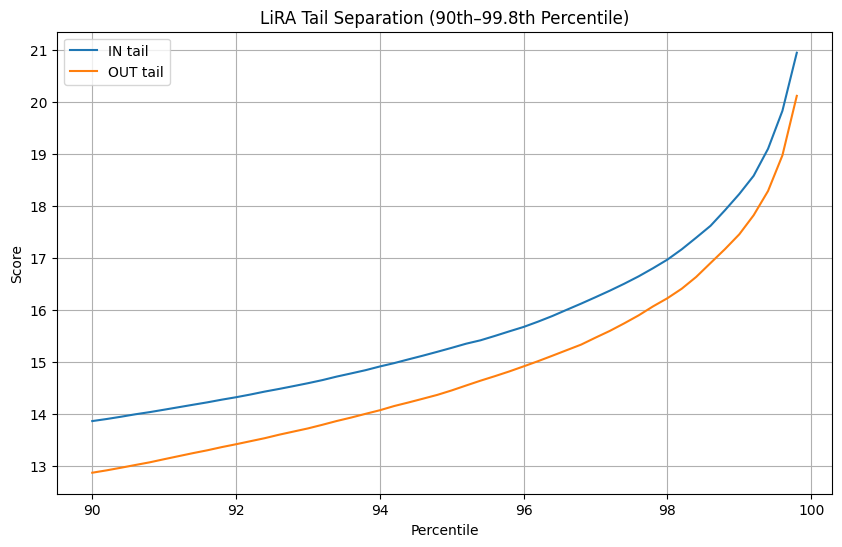

In [ ]:

#Plot Statistiscs
member_scores = []
nonmember_scores = []

for scores in all_in_scores.values():
    member_scores.extend(scores)

for scores in all_out_scores.values():
    nonmember_scores.extend(scores)

mu_in = np.mean(member_scores)
sigma_in = max(np.std(member_scores), 1e-6)
mu_out = np.mean(nonmember_scores)
sigma_out = max(np.std(nonmember_scores), 1e-6)

print(f"mu_in={mu_in}, sigma_in={sigma_in}")
print(f"mu_out={mu_out}, sigma_out={sigma_out}")


# --------------------------------------------------
# STEP 3: Histogram overlap (MOST IMPORTANT)
# --------------------------------------------------

plt.figure(figsize=(10,6))

plt.hist(
    member_scores,
    bins=60,
    alpha=0.5,
    density=True,
    label="IN (members)"
)

plt.hist(
    nonmember_scores,
    bins=60,
    alpha=0.5,
    density=True,
    label="OUT (non-members)"
)

plt.xlabel("Phi / LiRA Statistic")
plt.ylabel("Density")
plt.title("LiRA IN vs OUT Score Distribution")
plt.legend()
plt.grid(True)
plt.show()


# --------------------------------------------------
# STEP 4: Percentile comparison (TAILS MATTER)
# --------------------------------------------------

percentiles = np.arange(1, 100)

in_percentiles = np.percentile(member_scores, percentiles)
out_percentiles = np.percentile(nonmember_scores, percentiles)

plt.figure(figsize=(10,6))

plt.plot(percentiles, in_percentiles, label="IN percentiles")
plt.plot(percentiles, out_percentiles, label="OUT percentiles")

plt.xlabel("Percentile")
plt.ylabel("Score")
plt.title("LiRA Percentile Curves (Tail Separation Check)")
plt.legend()
plt.grid(True)
plt.show()


# --------------------------------------------------
# STEP 5: Focus on high-percentile tail (critical for TPR@5%FPR)
# --------------------------------------------------

tail_percentiles = np.arange(90, 100, 0.2)

in_tail = np.percentile(member_scores, tail_percentiles)
out_tail = np.percentile(nonmember_scores, tail_percentiles)

plt.figure(figsize=(10,6))

plt.plot(tail_percentiles, in_tail, label="IN tail")
plt.plot(tail_percentiles, out_tail, label="OUT tail")

plt.xlabel("Percentile")
plt.ylabel("Score")
plt.title("LiRA Tail Separation (90th–99.8th Percentile)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# member_scores = []
# nonmember_scores = []

# for scores in all_in_scores.values():
#     member_scores.extend(scores)

# for scores in all_out_scores.values():
#     nonmember_scores.extend(scores)

# mu_in = np.mean(member_scores)
# sigma_in = max(np.std(member_scores), 1e-6)
# mu_out = np.mean(nonmember_scores)
# sigma_out = max(np.std(nonmember_scores), 1e-6)

# save the statistics
torch.save({
    "mu_in": mu_in,
    "sigma_in": sigma_in,
    "mu_out": mu_out,
    "sigma_out": sigma_out
}, "lira__logits_stats.pt")

In [ ]:
#testing TPR@5%FPR
def tpr_at_fpr(member_scores, nonmember_scores, fpr=0.05):

    threshold = np.percentile(nonmember_scores, 100 * (1 - fpr))

    return np.mean(np.array(member_scores) > threshold)

In [ ]:
print(f'TPR@5%FPR : {tpr_at_fpr(member_scores, nonmember_scores, fpr=0.05)}')

TPR@5%FPR : 0.07516964285714285
